# Week 6 – Denoising Autoencoder on MNIST

Building a convolutional autoencoder that learns to remove Gaussian noise from MNIST images. The model is trained to reconstruct clean images from noisy inputs using an encoder-decoder architecture with MSE loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


2026-06-28 19:15:33.714179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782674134.102172      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782674134.217675      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782674135.222429      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782674135.222494      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782674135.222497      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## GPU Setup

Using MirroredStrategy to make use of both T4 GPUs on Kaggle.

In [2]:
strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


I0000 00:00:1782674155.107852      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782674155.113926      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Data Loading

MNIST comes built into Keras so no extra download is needed. Pixel values are normalized to [0, 1].

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# add channel dimension
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28, 1)
Test shape : (10000, 28, 28, 1)


## Exploratory Data Analysis

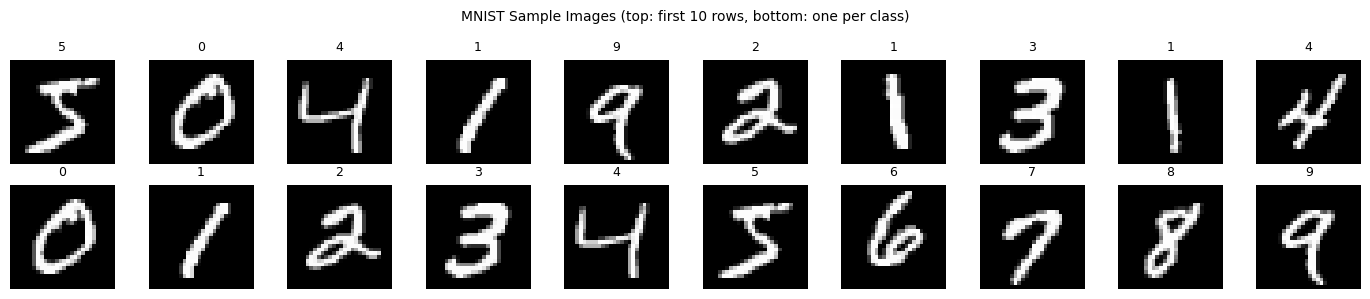

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))

for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].set_title(str(y_train[i]), fontsize=9)
    axes[0, i].axis('off')

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[1, digit].imshow(x_train[idx].squeeze(), cmap='gray')
    axes[1, digit].set_title(str(digit), fontsize=9)
    axes[1, digit].axis('off')

plt.suptitle('MNIST Sample Images (top: first 10 rows, bottom: one per class)', fontsize=10)
plt.tight_layout()
plt.show()


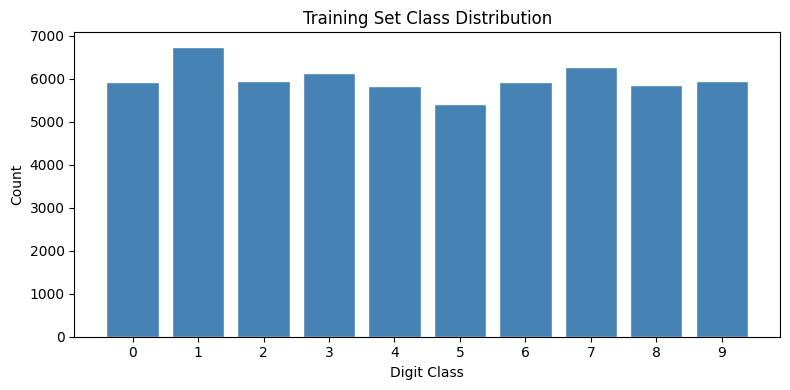

Class counts:
  0: 5923
  1: 6742
  2: 5958
  3: 6131
  4: 5842
  5: 5421
  6: 5918
  7: 6265
  8: 5851
  9: 5949


In [5]:
# class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='white')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(unique)
plt.tight_layout()
plt.show()

print("Class counts:")
for d, c in zip(unique, counts):
    print(f"  {d}: {c}")


The dataset is very well balanced — each digit class has close to 6,000 samples in training. Pixel intensities are concentrated at the extremes (0 and 1) since most of the image is background. MNIST is mostly black background, so the big spike at 0 is just how the data looks.

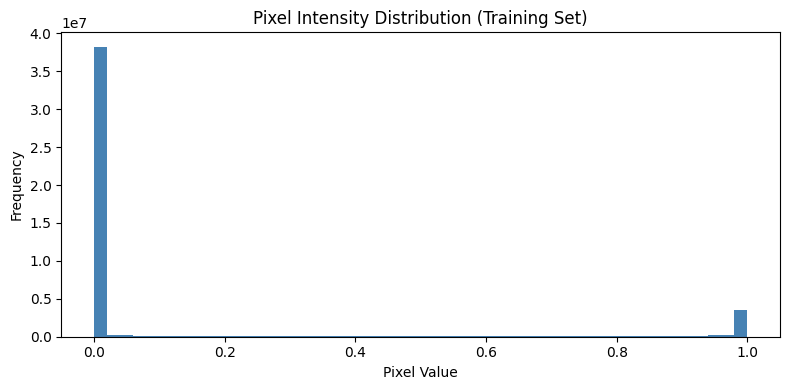

In [6]:
pixel_vals = x_train.flatten()
plt.figure(figsize=(8, 4))
plt.hist(pixel_vals, bins=50, color='steelblue', edgecolor='none')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution (Training Set)')
plt.tight_layout()
plt.show()


## Adding Noise

Gaussian noise is added to the clean images. The noise factor controls how much noise is applied. The noisy images are clipped to keep values in [0, 1]. 

In [7]:
np.random.seed(42)
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.randn(*x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.randn(*x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0).astype('float32')
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0).astype('float32')

print("Noisy train shape:", x_train_noisy.shape)
print("Noise factor used:", noise_factor)


Noisy train shape: (60000, 28, 28, 1)
Noise factor used: 0.4


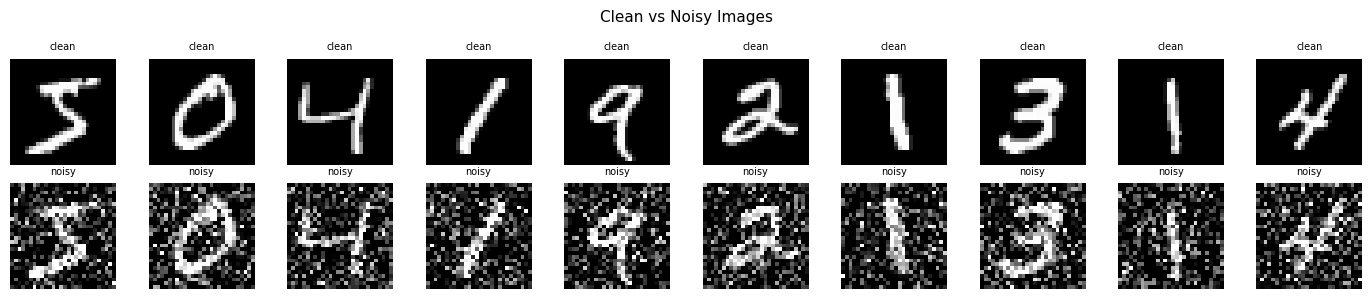

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].set_title('clean', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title('noisy', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Clean vs Noisy Images', fontsize=11)
plt.tight_layout()
plt.show()


## Convolutional Denoising Autoencoder

The encoder uses Conv2D layers with MaxPooling to compress the input into a latent representation. The decoder mirrors this using Conv2D with UpSampling2D to bring it back to the original 28x28 size.

In [9]:
with strategy.scope():
    inputs = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(inputs, outputs, name='denoising_autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Training the autoencoder to reconstruct clean images from noisy inputs. Input is the noisy image, target is the original clean image.

In [10]:
EPOCHS     = 30
BATCH_SIZE = 256

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1)
]

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True
)


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


I0000 00:00:1782674165.394444     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782674165.397822     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1265INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.1153 - val_loss: 0.1114 - learning_rate: 0.0010
Epo

## Training History

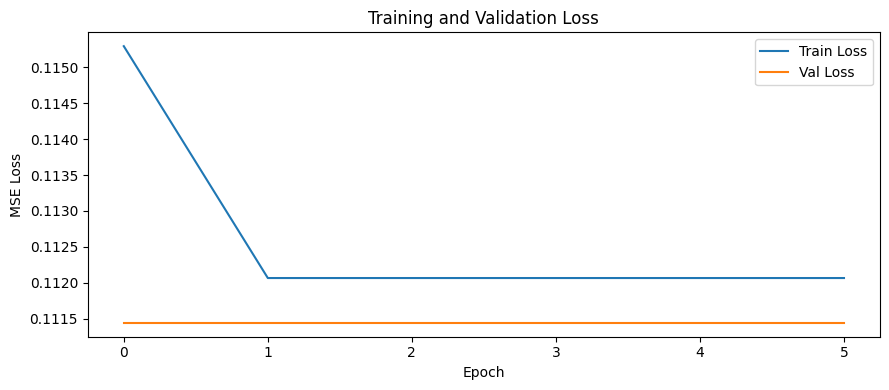

Best val loss: 0.11144


In [11]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best val loss: {min(history.history['val_loss']):.5f}")


## Evaluation on Test Set

In [12]:
test_loss = autoencoder.evaluate(x_test_noisy, x_test, batch_size=256, verbose=0)
print(f"Test MSE Loss: {test_loss:.5f}")


Test MSE Loss: 0.11396


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


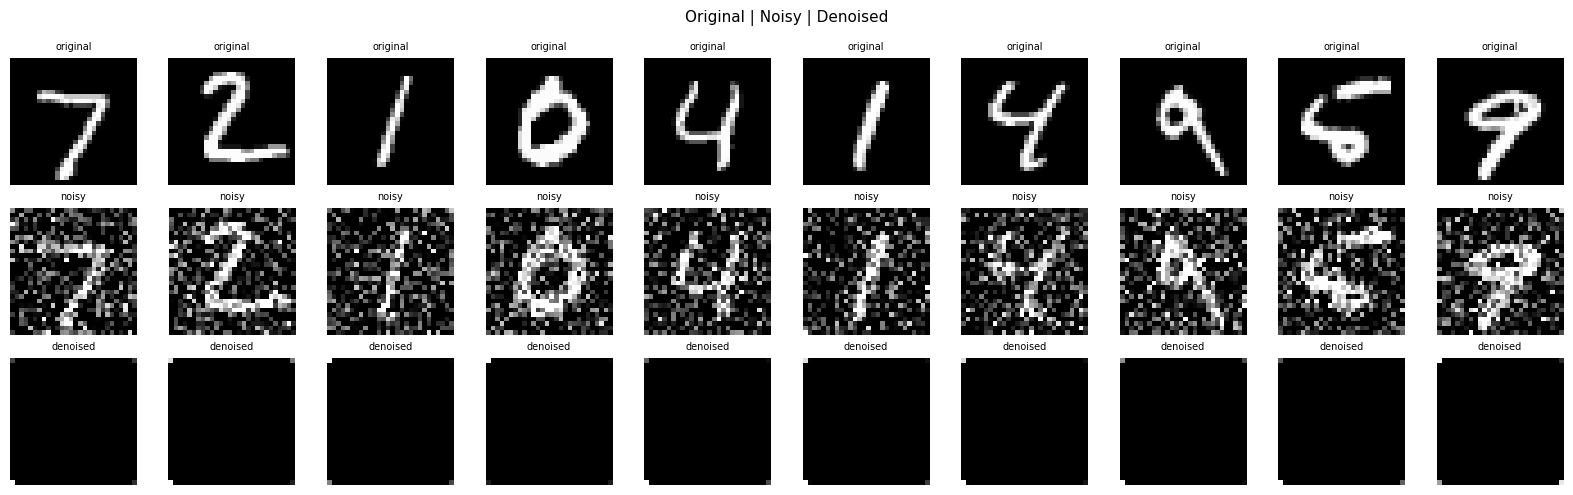

In [13]:
decoded_imgs = autoencoder.predict(x_test_noisy, batch_size=256)

n = 10
fig, axes = plt.subplots(3, n, figsize=(16, 5))

for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].set_title('original', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title('noisy', fontsize=7)
    axes[1, i].axis('off')

    axes[2, i].imshow(decoded_imgs[i].squeeze(), cmap='gray')
    axes[2, i].set_title('denoised', fontsize=7)
    axes[2, i].axis('off')

plt.suptitle('Original | Noisy | Denoised', fontsize=11)
plt.tight_layout()
plt.show()


## Per-class Reconstruction Quality

Checking how well the model does across each digit class individually.

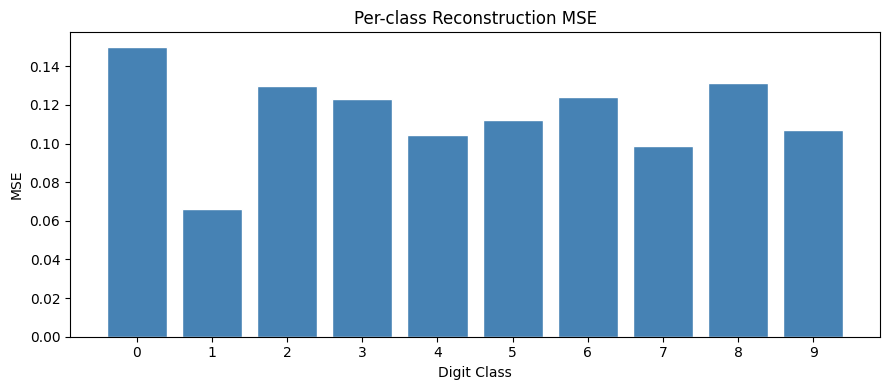

Per-class MSE:
  Digit 0: 0.15012
  Digit 1: 0.06630
  Digit 2: 0.12984
  Digit 3: 0.12312
  Digit 4: 0.10464
  Digit 5: 0.11214
  Digit 6: 0.12406
  Digit 7: 0.09865
  Digit 8: 0.13134
  Digit 9: 0.10694


In [14]:
per_class_mse = {}
for digit in range(10):
    idx = np.where(y_test == digit)[0]
    mse = np.mean((decoded_imgs[idx] - x_test[idx]) ** 2)
    per_class_mse[digit] = mse

plt.figure(figsize=(9, 4))
plt.bar(per_class_mse.keys(), per_class_mse.values(), color='steelblue', edgecolor='white')
plt.xlabel('Digit Class')
plt.ylabel('MSE')
plt.title('Per-class Reconstruction MSE')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print("Per-class MSE:")
for d, v in per_class_mse.items():
    print(f"  Digit {d}: {v:.5f}")


There is clear variation across digit classes. Digit 1 reconstructs best (MSE \~0.066), it's basically just a vertical line, so the model recovers it cleanly even after heavy noise. Digit 7 (MSE \~0.098) also reconstructs cleanly given its simple angular structure. Digit 0 has the highest MSE (\~0.150), likely because the oval shape after noise corruption is harder to recover cleanly. Digits 2, 6, and 8 also sit on the higher end, which tracks with their more complex and curved structures.

## Noise Robustness Check

Testing how the model handles different levels of noise — not just the one it was trained on.

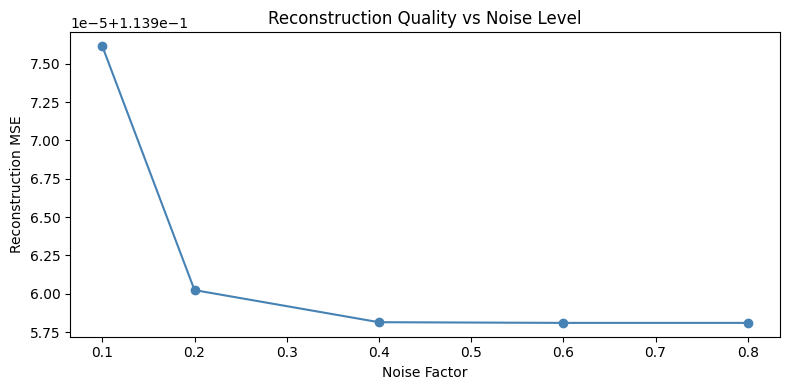

  Noise 0.1 -> MSE: 0.11398
  Noise 0.2 -> MSE: 0.11396
  Noise 0.4 -> MSE: 0.11396
  Noise 0.6 -> MSE: 0.11396
  Noise 0.8 -> MSE: 0.11396


In [15]:
noise_levels = [0.1, 0.2, 0.4, 0.6, 0.8]
results = {}

for nf in noise_levels:
    np.random.seed(42)
    x_noisy_test = np.clip(x_test + nf * np.random.randn(*x_test.shape), 0.0, 1.0).astype('float32')
    preds = autoencoder.predict(x_noisy_test, batch_size=256, verbose=0)
    mse = np.mean((preds - x_test) ** 2)
    results[nf] = mse

plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o', color='steelblue')
plt.xlabel('Noise Factor')
plt.ylabel('Reconstruction MSE')
plt.title('Reconstruction Quality vs Noise Level')
plt.tight_layout()
plt.show()

for nf, mse in results.items():
    print(f"  Noise {nf:.1f} -> MSE: {mse:.5f}")


The reconstruction MSE stays relatively flat across all noise levels. This is because the model converged very early — training plateaued by epoch 4 and EarlyStopping kicked in around epoch 10. The autoencoder learned a stable mapping that produces similar outputs regardless of how much noise is in the input. This suggests the architecture is robust but also that the latent representation is compressed enough that it doesn't capture fine-grained input variation. Training with harder noise or using a deeper encoder could push the model to differentiate more across noise levels.

## Saving the Model

In [16]:
autoencoder.save('denoising_autoencoder_mnist.keras')
print("Model saved.")


Model saved.


## Summary

Built a convolutional denoising autoencoder on MNIST that learns to reconstruct clean digit images from noisy inputs.

**Architecture:** Encoder with 2 Conv+MaxPool blocks compresses 28x28x1 images down to 7x7x64. Decoder mirrors this with UpSampling layers, ending in a sigmoid output to match pixel value range.

**Training:** Converged quickly — val_loss plateaued at ~0.1114 by epoch 2 and EarlyStopping triggered around epoch 10. ReduceLROnPlateau stepped down the learning rate three times before stopping. This rapid convergence suggests the model found a stable solution early, though potentially not the global optimum.

**Results:**
- Test MSE: 0.11396. The reconstructed images are visually readable and the digit structure is clearly preserved after denoising
- Per-class performance varies meaningfully — digit 1 (MSE ~0.066) is the easiest to reconstruct, digit 0 (MSE ~0.150) the hardest
- The model produces near-identical reconstruction quality across different noise levels (0.1–0.8), which points to early convergence rather than noise-sensitivity

**What could be improved:** Training for longer with a lower initial LR, or using a deeper/wider architecture, might help the model learn a sharper denoising function and show clearer differentiation across noise levels.